In [1]:
# =========================================
# 1. Imports
# =========================================
from pathlib import Path
import argparse
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

BASE_PATH = Path.cwd()
if not (BASE_PATH / "data" / "whodecide" / "processed" / "selects_2023_clean.csv").exists():
    BASE_PATH = BASE_PATH.parent


c:\Users\jmart\Documents\05_Studium\04_Programmierprojekte\04_Semester\DigitalStorytellingAndVisualisation\visualisierungsprojekt\PODSV_Visualisierungsprojekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================
# 2. CSV-Datei einlesen
# =========================================

PROCESSED_SELECTS_PATH = BASE_PATH / "data" / "whodecide" / "processed" / "selects_2023_clean.csv"
df = pd.read_csv(PROCESSED_SELECTS_PATH)

df.shape
df.head()

C:\Users\jmart\AppData\Local\Temp\ipykernel_60084\1392333522.py:6: DtypeWarning: Columns (206,207,208,209,210,211,212,213,214,215) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_SELECTS_PATH)


,userid,langint,imode,indate_paper,language_paper,intstart,intend,finished,completion_rate,totaltime,...,weight_tot,weight_t_zh,weight_p_zh,weight_tot_zh,weight_t_ti,weight_p_ti,weight_tot_ti,weight_t_ge,weight_p_ge,weight_tot_ge
0,1001,2,1,,,11/7/2023 14:28:40,11/16/2023 21:19:15,1,2,"13370,5666666667",...,",599246512333914",1,1,1,1,1,1,"1,49920369",1,"1,49920369"
1,1002,1,1,,,10/24/2023 13:26:04,10/24/2023 13:51:42,1,2,"25,6333333333333",...,",976448777640773",1,1,1,1,1,1,1,1,1
2,1003,1,1,,,11/13/2023 20:36:39,11/13/2023 20:56:14,1,2,"19,5666666666667",...,"1,18620046322414",1,1,1,1,1,1,1,1,1
3,1004,1,1,,,10/24/2023 7:41:41,10/24/2023 8:13:56,1,2,"32,2333333333333",...,",552334100995496",1,1,1,1,1,1,1,1,1
4,1005,1,1,,,11/3/2023 13:42:10,11/3/2023 14:05:17,1,2,"23,1166666666667",...,",188235121344307",1,1,1,1,1,1,1,1,1


In [3]:
df.columns

Index(['userid', 'langint', 'imode', 'indate_paper', 'language_paper',
       'intstart', 'intend', 'finished', 'completion_rate', 'totaltime',
       ...
       'weight_tot', 'weight_t_zh', 'weight_p_zh', 'weight_tot_zh',
       'weight_t_ti', 'weight_p_ti', 'weight_tot_ti', 'weight_t_ge',
       'weight_p_ge', 'weight_tot_ge'],
      dtype='object', length=308)

In [4]:
df["f11100rec"].value_counts(dropna=False)

f11100rec
 1     3268
 0     1716
-99      47
-98       2
Name: count, dtype: int64

In [5]:
df["f11800main6"].value_counts(dropna=False)

f11800main6
       1755
40      769
30      619
21      525
10      520
350     293
50      233
60      200
-99     110
998       9
Name: count, dtype: int64

In [6]:
df["birthyear"].describe()

count    5033.000000
mean     1962.087224
std       137.755901
min       -99.000000
25%      1957.000000
50%      1969.000000
75%      1986.000000
max      2005.000000
Name: birthyear, dtype: float64

In [7]:
# remove missing turnout values
df = df[df["f11100rec"] >= 0]

In [8]:
def assign_generation(year):
    " Weist einem Geburtsjahr eine Generation zu."
    " Fehlende Werte werden als NA zurückgegeben."
    if pd.isna(year):
        return pd.NA
    elif year <= 1945:
        return "Silent Generation"
    elif 1946 <= year <= 1964:
        return "Baby Boomers"
    elif 1965 <= year <= 1980:
        return "Generation X"
    elif 1981 <= year <= 1996:
        return "Millennials"
    else:
        return "Generation Z"

In [9]:
# Generationen zuweisen
df["generation"] = df["birthyear"].apply(assign_generation)

In [10]:
# Überprüfen der Verteilung der Generationen
df["generation"].value_counts(dropna=False)

generation
Baby Boomers         1611
Generation X         1365
Millennials          1111
Generation Z          519
Silent Generation     378
Name: count, dtype: int64

In [11]:
###
# Chart 1: Wahlbeteiligung nach Generationen visualisieren
###
#  Wahlbeteiligung nach Generationen berechnen
df["voted"] = df["f11100rec"]
df["voted"].value_counts()

voted
1    3268
0    1716
Name: count, dtype: int64

In [12]:
# Wahlbeteiligung nach Generationen berechnen
turnout = df.groupby("generation")["voted"].mean() * 100
turnout

generation
Baby Boomers         75.356921
Generation X         66.007326
Generation Z         47.398844
Millennials          56.795680
Silent Generation    73.015873
Name: voted, dtype: float64

In [13]:
generation_order = [
    "Silent Generation",
    "Baby Boomers",
    "Generation X",
    "Millennials",
    "Generation Z"
]

turnout = turnout.reindex(generation_order)
turnout

generation
Silent Generation    73.015873
Baby Boomers         75.356921
Generation X         66.007326
Millennials          56.795680
Generation Z         47.398844
Name: voted, dtype: float64

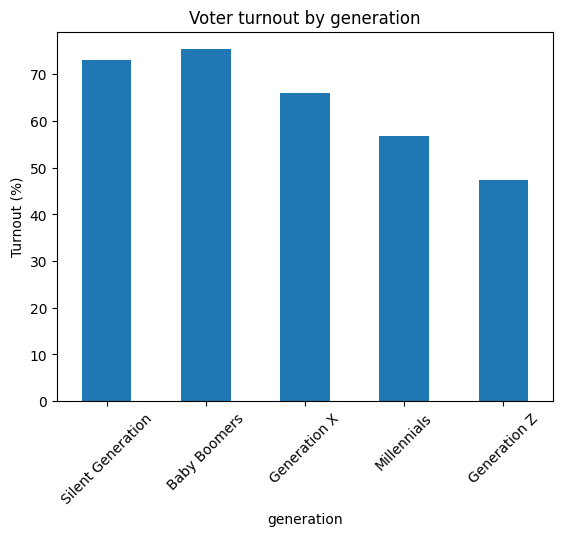

In [14]:
###
# Wahlbeteiligung nach Generationen visualisieren
###
turnout.plot(kind="bar")
plt.ylabel("Turnout (%)")
plt.title("Voter turnout by generation")
plt.xticks(rotation=45)
plt.show()

In [15]:
###
# statistische Analyse: Chi-Quadrat-Test für Unabhängigkeit
# Hier wird getestet, ob die Wahlbeteiligung (voted) von der Generation (generation) abhängig ist.
###
contingency_table = pd.crosstab(df["generation"], df["voted"])
contingency_table

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 191.5453390189887
p-value: 2.467236812181094e-40


In [16]:
###
# Chart 2: Politisches Interesse über Generationen hinweg
###
# Daten vorbereiten

df["political_interest"] = df["f10100"].replace([-99, -98], np.nan)

In [17]:
###
# politisches Interesse über Generationen hinweg
# ausführen
###
interest_by_generation = (
    df.groupby("generation")["political_interest"]
      .mean()
      .reindex(generation_order)
)

interest_by_generation

generation
Silent Generation    2.968170
Baby Boomers         2.854024
Generation X         2.673035
Millennials          2.559856
Generation Z         2.443160
Name: political_interest, dtype: float64

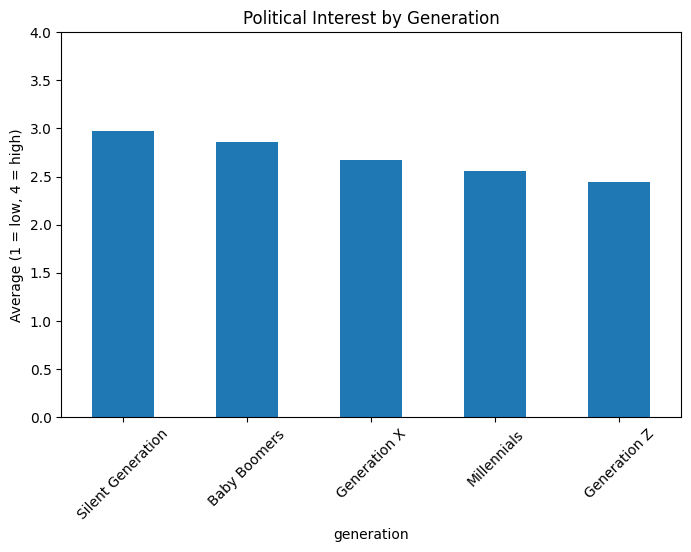

In [18]:
###
# politisches Interesse über Generationen hinweg
# visualisieren
###
plt.figure(figsize=(8, 5))
interest_by_generation.plot(kind="bar")

plt.title("Political Interest by Generation")
plt.ylabel("Average (1 = low, 4 = high)")
plt.xticks(rotation=45)
plt.ylim(0, 4)

plt.show()

In [19]:
###
# Anova: Politisches Interesse über Generationen hinweg
# Daten vorbereiten
###
groups = [
    group["political_interest"].dropna()
    for name, group in df.groupby("generation")
]

In [20]:
###
# Anova-test durchführen
###
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 48.014174531429504
p-value: 1.1278489959358468e-39


In [21]:
###
# Tukey-HSD-Test:
# Nachdem die ANOVA gezeigt hat, dass sich das politische Interesse zwischen den Generationen insgesamt unterscheidet,
# wird dieser Test verwendet, um zu bestimmen, zwischen welchen konkreten Generationen signifikante Unterschiede bestehen.
# Dabei wird berücksichtigt, dass mehrere Gruppenvergleiche gleichzeitig durchgeführt werden.
###
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_tukey = df[["generation", "political_interest"]].dropna()

tukey = pairwise_tukeyhsd(
    endog=df_tukey["political_interest"],
    groups=df_tukey["generation"],
    alpha=0.05
)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1          group2      meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Baby Boomers      Generation X   -0.181    0.0 -0.2612 -0.1008   True
Baby Boomers      Generation Z  -0.4109    0.0 -0.5207  -0.301   True
Baby Boomers       Millennials  -0.2942    0.0 -0.3791 -0.2092   True
Baby Boomers Silent Generation   0.1141 0.0905 -0.0104  0.2387  False
Generation X      Generation Z  -0.2299    0.0 -0.3421 -0.1176   True
Generation X       Millennials  -0.1132 0.0041 -0.2011 -0.0252   True
Generation X Silent Generation   0.2951    0.0  0.1685  0.4218   True
Generation Z       Millennials   0.1167 0.0468   0.001  0.2324   True
Generation Z Silent Generation    0.525    0.0  0.3778  0.6722   True
 Millennials Silent Generation   0.4083    0.0  0.2786   0.538   True
---------------------------------------------------------------------


In [22]:
###
# Chart 3 Vertrauen in Institutionen über Generationen hinweg
###
# Daten vorbereiten
trust_vars = [
    "f11301",  # Parliament
    "f11302",  # Government
    "f11305",  # Parties
]

df[trust_vars] = df[trust_vars].replace([-99, -98], np.nan)

Stehen geblieben bei Chart 3..

# Who decides? — Fahrplan ( notiz für mich)

## Ziel
Untersuchen, wie sich politische Teilnahme zwischen Generationen unterscheidet
und welche Faktoren diese Unterschiede erklären.

---

## 1. Wahlbeteiligung (Turnout)

- Ältere Generationen wählen deutlich häufiger
- Jüngere Generationen beteiligen sich weniger

👉 Zentrale Beobachtung:
Es gibt einen klaren Unterschied in politischer Teilnahme

---

## 2. Politisches Interesse

- Ältere sind etwas interessierter
- Unterschied ist vorhanden, aber relativ klein

👉 Interpretation:
Interesse erklärt die Unterschiede in der Wahlbeteiligung nur teilweise

---

## 3. Vertrauen in Institutionen

- Jüngere Generationen haben weniger Vertrauen
- Parteien haben generell das niedrigste Vertrauen

👉 Interpretation:
Vertrauen könnte ein wichtigerer Faktor für Teilnahme sein als Interesse

---

## 4. Gründe für Nicht-Wählen (optional)

- Desinteresse
- keine überzeugende Partei
- Gefühl, dass Wählen nichts bringt

👉 Interpretation:
Geringe Teilnahme hängt oft mit fehlendem Vertrauen und Engagement zusammen

---

## Gesamt-Story

1. Ältere Generationen entscheiden mehr (höhere Wahlbeteiligung)
2. Sie sind etwas interessierter
3. Aber: Interesse allein reicht nicht als Erklärung
4. Vertrauen in Institutionen scheint ein zentraler Faktor zu sein

👉 Schluss:
Unterschiede in politischer Teilnahme lassen sich durch eine Kombination aus Interesse und Vertrauen erklären,
wobei Vertrauen vermutlich die wichtigere Rolle spielt.